# DS 542 Spring 2026 Project 1

In this class, projects are basically longer (e.g. 2-week) homework assignments here you are expected to do more experimentation and coding.

* Your task for this project is to improve the training results for a fixed architecture model for the Tree-or-Not data set.
* Your model will be constrained to use the architecture in this template.
* To train a better model, you will instead explore picking appropriate early stopping rules, initialization, learning rate, regularization and data augmentation.


## Background

This notebook builds a model detecting trees in images.
The data set is available on GitHub at https://github.com/DL4DS/tree-or-not or on the Shared Compute Cluster at `/projectnb/dl4ds/materials/datasets/tree-or-not`.

The initial data set consists of about 500 pictures. Most of them are from the Boston area, but some are from around the globe. Most of them were taken outside, but some were taken inside or in more exotic locations. Many other factors such as lighting, weather, and confounding bushes will make this a challenging problem.

## Assignment Directions

1. Run the provided notebook and confirm basic functionality.
2. Inspect the dataset. Do you see any labeling errors? (5%)
2. Explore training improvements in each of the following categories and report the results - early stopping, initialization, learning rate, regularization and data augmentation. (25%)
3. Take the best configuration of each of the five training modifications and apply them all to see what overall improvement you can get. (30%)
4. Explain as best you can why each improvement was included or not included in the best performing model. (10%)
5. Save the best performing model for further evaluation by the auto-grader. (30%)


## Modules

In [17]:
import imageio.v2 as imageio
import livelossplot
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torcheval.metrics
import numpy as np
import random
import torch.nn.functional as F
import torchvision.transforms.functional as TF
from torchvision.transforms import InterpolationMode

## GPU Access

In [18]:
def to_gpu(t):
    if torch.cuda.is_available():
        return t.cuda()
    return t

def to_numpy(t):
    return t.detach().cpu().numpy()

device = to_gpu(torch.ones(1,1)).device
device

device(type='cuda', index=0)

## Set Seed for Reproducibility

In [19]:
# NOTE: cuda also has a random seed, so we need to set that as well for reproducibility
def set_seed(seed=42):
    import torch

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

## Load Data

If you are not running on the SCC, fetch the data from https://github.com/dl4ds/tree-or-not as needed. For example, you could use `git clone` to make a local copy and update `data_dir` below.

If you are running on SCC, the data is already loaded so just leave `data_dir` as is.

In [20]:
# If you are running locally, change this path to the local path of the tree-or-not data set.
data_dir = "./tree-or-not"


In [21]:
# DO NOT CHANGE THIS CELL

image_width = 256

def load_data_set(data_set_name):
    labels = pd.read_csv(f"{data_dir}/{data_set_name}.tsv", sep="\t")

    file_names = []
    images = []
    targets = []
    for i in range(labels.shape[0]):
        row = labels.iloc[i]
        try:
            image = imageio.imread(f"{data_dir}/images{image_width}/{row['filename']}")[...]
        except:
            print("SKIPPING ", row['filename'], "MISSING")
            continue

        if image.shape[0] != image.shape[1] * 3 // 4:
            print("SKIPPING ", row['filename'], image.shape)
            continue

        # convert from 0-255 to 0.0-1.0
        image = image / 255
        # prepend axis with length one
        # image = image.reshape(1, *image.shape)
        image = torch.tensor(image, device=device, dtype=torch.float32)
        # permute image dimensions to put color channel first
        image = torch.permute(image, [2, 0, 1])

        file_names.append(row['filename'])
        images.append(image)
        targets.append(row["target"])

    images = torch.stack(images)

    targets = torch.tensor(targets, device=device, dtype=torch.float32)
    targets = targets.long()

    return (file_names, images, targets)

train_data_set = load_data_set("train")
for t in train_data_set[1:]:
    print("TRAIN", t.shape, t.dtype, t.device)
(train_file_names, train_X, train_Y) = train_data_set

validation_data_set = load_data_set("validation")
for t in validation_data_set[1:]:
    print("VALIDATION", t.shape, t.dtype, t.device)
(validation_file_names, validation_X, validation_Y) = validation_data_set

validation2_data_set = load_data_set("validation2")
for t in validation2_data_set[1:]:
    print("VALIDATION2", t.shape, t.dtype, t.device)
(validation2_file_names, validation2_X, validation2_Y) = validation2_data_set

TRAIN torch.Size([292, 3, 192, 256]) torch.float32 cuda:0
TRAIN torch.Size([292]) torch.int64 cuda:0
VALIDATION torch.Size([97, 3, 192, 256]) torch.float32 cuda:0
VALIDATION torch.Size([97]) torch.int64 cuda:0
SKIPPING  IMG_1585.png (256, 192, 3)
VALIDATION2 torch.Size([108, 3, 192, 256]) torch.float32 cuda:0
VALIDATION2 torch.Size([108]) torch.int64 cuda:0


## Inspect the Data Set

This is a handy way to inspect the dataset. Randomly choose 4 images at a time.

It is a common oversight to not look closely at the dataset. It's often worthwhile to ensure everything is labeled correctly.

### Inspect the training set

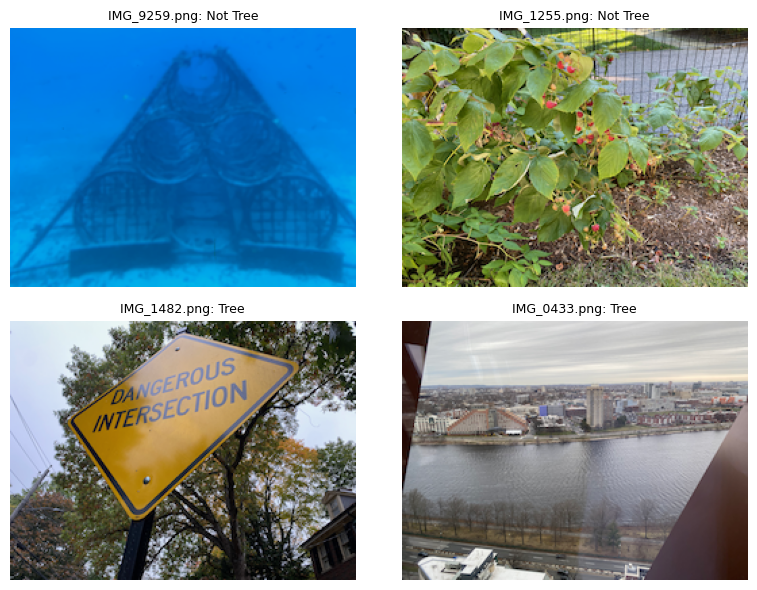

In [22]:
# You can rerun this cell to randomly inspect different images.

idx = torch.randperm(train_X.shape[0])[:4]
fig, axes = plt.subplots(2, 2, figsize=(8, 6))

label_names = {0: "Not Tree", 1: "Tree"}

for ax, i in zip(axes.flatten(), idx):
    ax.imshow(to_numpy(torch.permute(train_X[i, :, :, :], (1, 2, 0))))
    label = label_names.get(int(train_Y[i]), str(int(train_Y[i])))
    ax.set_title(f"{train_file_names[int(i)]}: {label}", fontsize=9)
    ax.axis("off")

plt.tight_layout()

### Inspect the validation set

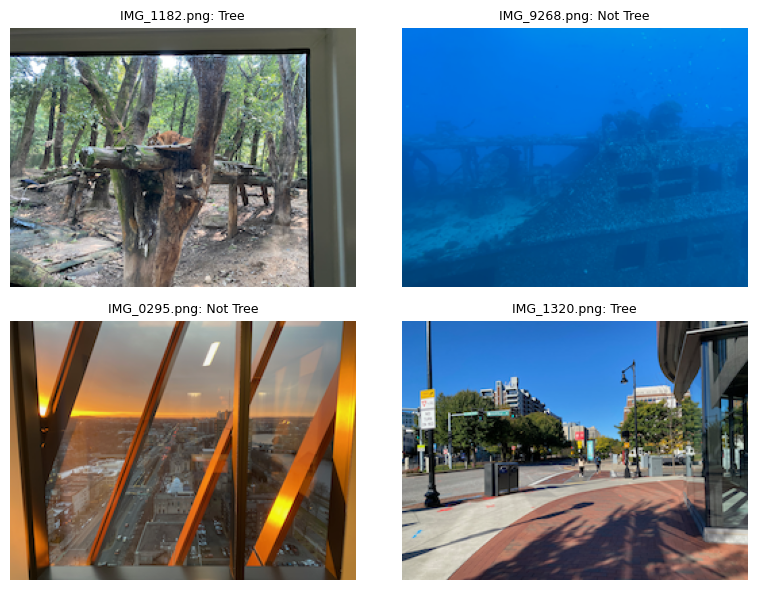

In [23]:
# You can rerun this cell to randomly inspect different images.

idx = torch.randperm(validation_X.shape[0])[:4]
fig, axes = plt.subplots(2, 2, figsize=(8, 6))

label_names = {0: "Not Tree", 1: "Tree"}

for ax, i in zip(axes.flatten(), idx):
    ax.imshow(to_numpy(torch.permute(validation_X[i, :, :, :], (1, 2, 0))))
    label = label_names.get(int(validation_Y[i]), str(int(validation_Y[i])))
    ax.set_title(f"{validation_file_names[int(i)]}: {label}", fontsize=9)
    ax.axis("off")

plt.tight_layout()

### Inspect the 2nd Validation Set

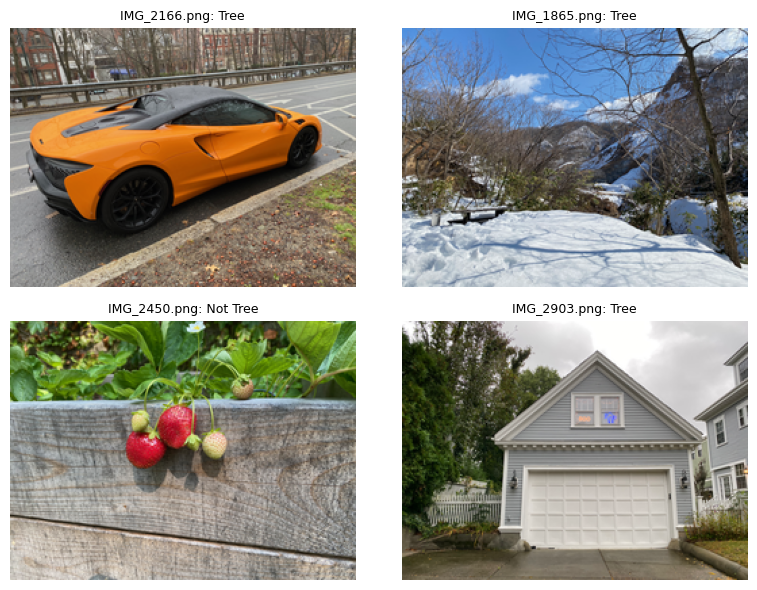

In [24]:
# You can rerun this cell to randomly inspect different images.
idx = torch.randperm(validation2_X.shape[0])[:4]
fig, axes = plt.subplots(2, 2, figsize=(8, 6))

label_names = {0: "Not Tree", 1: "Tree"}

for ax, i in zip(axes.flatten(), idx):
    ax.imshow(to_numpy(torch.permute(validation2_X[i, :, :, :], (1, 2, 0))))
    label = label_names.get(int(validation2_Y[i]), str(int(validation2_Y[i])))
    ax.set_title(f"{validation2_file_names[int(i)]}: {label}", fontsize=9)
    ax.axis("off")

plt.tight_layout()

<!-- BEGIN QUESTION -->

## Dataset Evaluation (5%)

What is your assessment of the dataset? Are all the images labeled well? Do you see any anomolies? If so, list the image names and what you think the labels should be.

### ANS: 
Based on random sampling and manual inspection of the training images, the labeling of “Tree” appears to follow a relatively strict, biology-inspired definition of a tree (i.e., woody plants with a distinct trunk). Smaller bushes or shrubs are generally not labeled as trees (e.g., IMG_1523), suggesting a consistent labeling rule that distinguishes trees from lower vegetation.

The dataset is also able to correctly identify trees in mid-distance scenes (e.g., IMG_2049), including images containing large forest areas or dense tree clusters. However, in cases where trees appear only as distant silhouettes or shadows in far-background landscapes (e.g., IMG_2668), the labeling becomes more restrictive and such images are sometimes classified as “Not Tree.”

Overall, I did not observe any clear labeling errors. While there are some borderline or ambiguous cases—particularly involving distant or densely clustered vegetation—the labels appear internally consistent rather than incorrect. The ambiguity seems to stem from definitional boundaries rather than mislabeling.

<!-- END QUESTION -->

## Model Building

> Do not modify the architecture of the network. You can add regularizations that apply during training but don't effect the architecture.

In [25]:
class TreeNetwork(torch.nn.Module):
    def __init__(self):
        super().__init__()

        self.conv_0 = torch.nn.Conv2d(in_channels=3, out_channels=5, kernel_size=5, stride=2, device=device)
        self.conv_1 = torch.nn.Conv2d(in_channels=5, out_channels=5, kernel_size=5, stride=2, device=device)
        self.conv_2 = torch.nn.Conv2d(in_channels=5, out_channels=5, kernel_size=5, stride=2, device=device)
        self.conv_3 = torch.nn.Conv2d(in_channels=5, out_channels=5, kernel_size=5, stride=2, device=device)
        self.fc_3 = torch.nn.Linear(585, 2)

        self.relu = torch.nn.ReLU()

    def forward(self, X):

        X = self.conv_0(X)
        X = self.relu(X)

        X = self.conv_1(X)
        X = self.relu(X)

        X = self.conv_2(X)
        X = self.relu(X)

        X = self.conv_3(X)
        X = self.relu(X)

        # flatten channels and image dimensions
        X = X.reshape(X.shape[:-3] + (-1,))

        X = self.fc_3(X)

        return X

test_model = TreeNetwork().to(device)
test_output = test_model(train_X[:5,:,:,:])
assert test_output.shape == (5, 2)
del test_output

In [26]:
loss_function = torch.nn.CrossEntropyLoss()

In [27]:
DEFAULT_EPOCHS = 500

def train_model(model_class, epochs=DEFAULT_EPOCHS, learning_rate=1e-4, **kwargs):
    """
    Train a model for a given number of epochs and plot the loss and accuracy for the training and validation sets.
    """
    model = model_class(**kwargs)
    if torch.cuda.is_available():
        model = model.cuda()

    model = torch.nn.DataParallel(model)
    model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    liveloss = livelossplot.PlotLosses()
    for i in range(epochs):
        model.train()

        optimizer.zero_grad(set_to_none=True)
        prediction = model(train_X)
        loss = loss_function(prediction, train_Y)
        loss.backward()
        optimizer.step()

        if (i + 1) % 50 == 0:
            liveloss_updates = {}
            with torch.no_grad():
                model.eval()

                def get_metrics(metrics_prefix, metrics_X, metrics_Y):
                    metrics_prediction = model(metrics_X)

                    return {
                        f"{metrics_prefix}loss": loss_function(metrics_prediction, metrics_Y),
                        f"{metrics_prefix}accuracy": torcheval.metrics.functional.multiclass_accuracy(torch.argmax(metrics_prediction, dim=-1), metrics_Y)
                    }
                
                liveloss_updates.update(get_metrics("", train_X, train_Y))
                liveloss_updates.update(get_metrics("val_", validation_X, validation_Y))

            liveloss_updates = {k: to_numpy(v) for k, v in liveloss_updates.items()}
            liveloss.update(liveloss_updates,
                            current_step=i+1)
            liveloss.send()

    return model

# We use a fixed seed for reproducibility
set_seed(42)

test_model = train_model(TreeNetwork, epochs=1)
del test_model

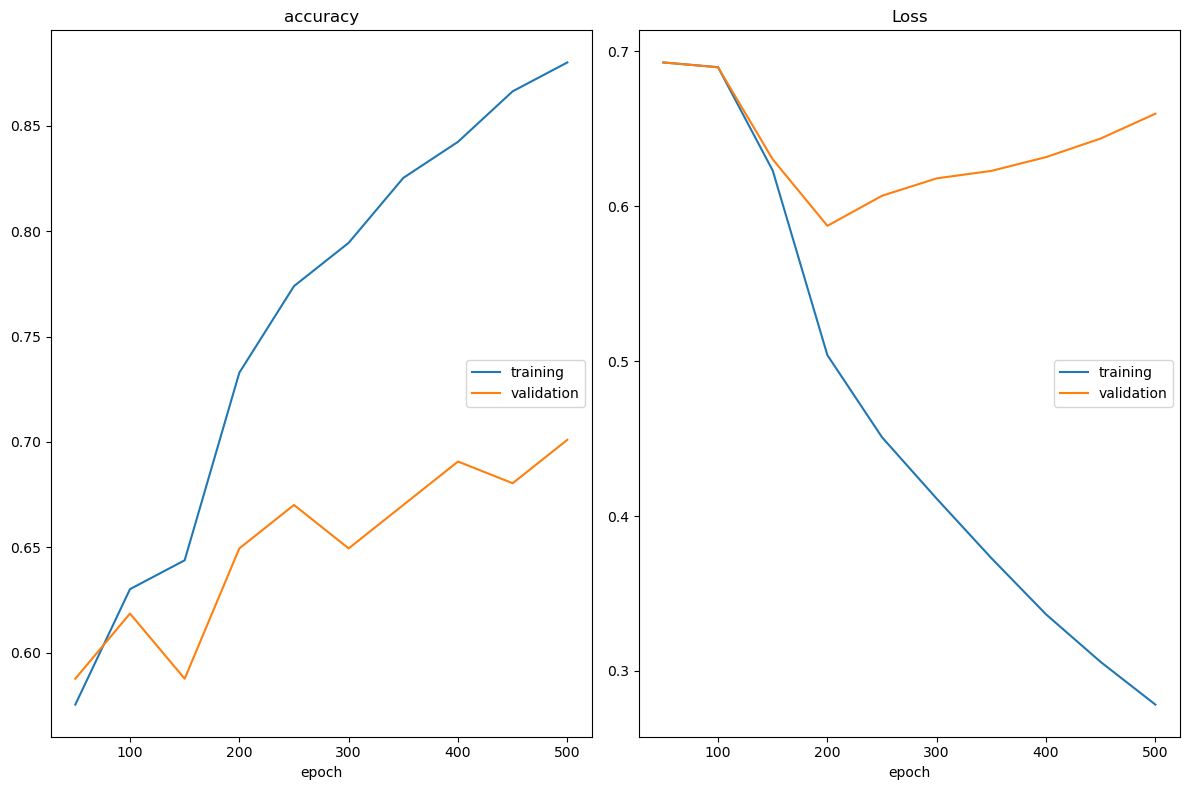

accuracy
	training         	 (min:    0.575, max:    0.880, cur:    0.880)
	validation       	 (min:    0.588, max:    0.701, cur:    0.701)
Loss
	training         	 (min:    0.278, max:    0.693, cur:    0.278)
	validation       	 (min:    0.587, max:    0.693, cur:    0.660)


In [45]:
set_seed(42)
base_model= train_model(TreeNetwork, epochs=DEFAULT_EPOCHS)

## Training Improvements (25%)

In this section you will experiment with five different kinds of training improvements:
1. Early stoppiong
2. Initialization
3. Learning Rates
4. Regularization
5. Data Augmentation

**Your description must be specific to this data set and baseline training process.**

You do not need to describe how these methods work in general, and generalities may cost points for making your answer less concise.

You can train your models below with a different number of epochs than used above.

Warning:
Your training improvements will be sanity checked when models are built with them below.

If your training improvement does not improve the validation accuracy, then it will deemed inappropriate for this specific data set and architecture, and you will lose points here.

<!-- BEGIN QUESTION -->

### Early Stopping (5% of the 25%)

The baseline model overfits a lot.

Update the training strategy to implement early stopping to avoid entering the overfitting regime. There are multiple ways to do this.

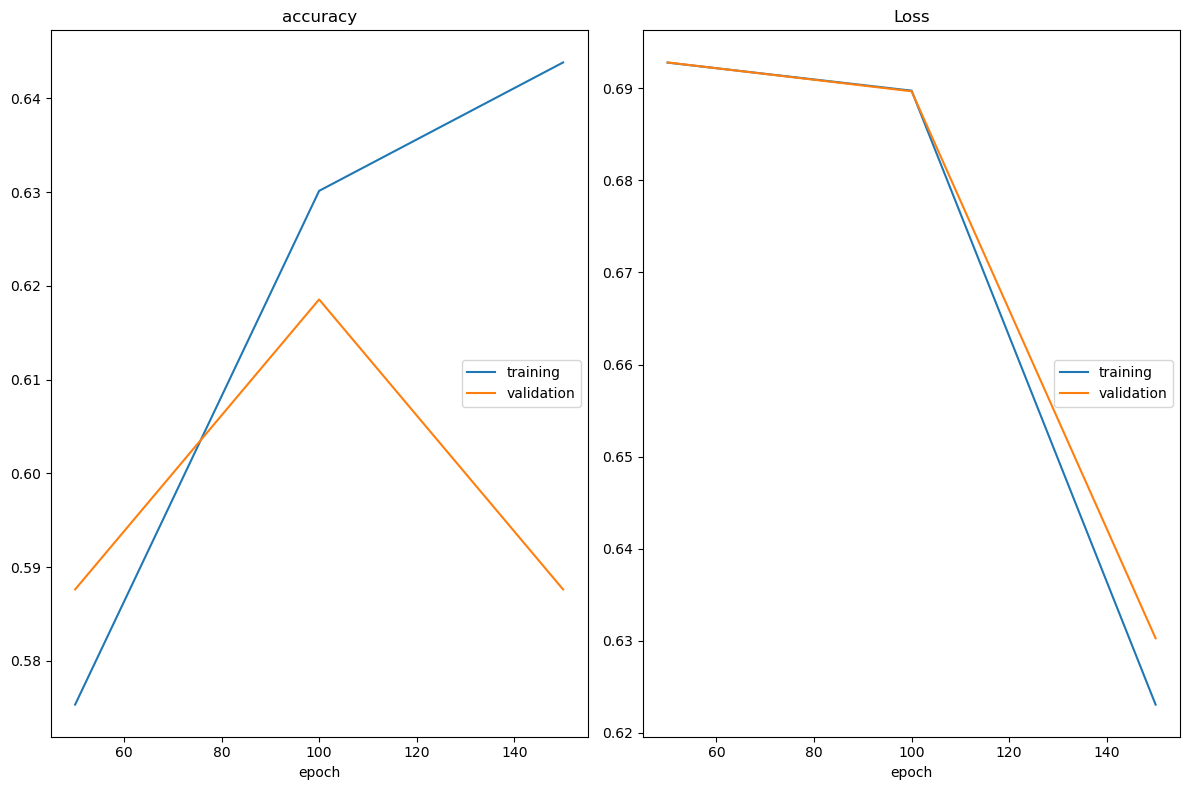

accuracy
	training         	 (min:    0.575, max:    0.644, cur:    0.644)
	validation       	 (min:    0.588, max:    0.619, cur:    0.588)
Loss
	training         	 (min:    0.623, max:    0.693, cur:    0.623)
	validation       	 (min:    0.630, max:    0.693, cur:    0.630)


In [29]:
# Best Model for Early Stopping 
# NOTE: We use the base training model, train_model(), but with the best epoch found by early stopping

# The best_epoch comes from the training and validation loss and accuracy plots. We choose the epoch with the lowest validation loss.
best_epoch = 150

set_seed(42)
early_stopping_model= train_model(TreeNetwork, epochs=best_epoch)

What are all the different ways you can implement early stopping?

Which way did you implement?

What was your validation accuracy and loss before and after early stopping?

### ANS:  
Early stopping can be implemented by monitoring validation loss during training. Training can be stopped when the validation performance stops improving for a certain number of epochs (patience-based stopping), or when the validation loss reaches its minimum value and begins to increase, which indicates the overfitting.  

In this experiment, I monitored the validation loss for the baseline model (the very first plot), and selected the best epoch with the lowest validation loss on the validation set (epoch = 150). Finally, set it as the early stopping point.

Before applying early stopping (base_model, epoch = 500):  
Validation accuracy: $0.701$  
Validation loss: $0.660$  

After applying early stopping (early_stopping_model, epoch = 150):  
Validation accuracy: $0.588$  
Validation loss: $0.633$  

Notice that since I use the set_seed(42) function for reproducibility, the training process becomes deterministic and the results remain consistent across runs. As a result, the early stopping point and the validation metrics are determined based on this fixed training trajectory. Although the validation accuracy slightly decreases after applying early stopping, the validation loss improves significantly. This is because cross-entropy loss also reflects the confidence of the predictions, while accuracy only measures whether the prediction is correct. Therefore, selecting the epoch with the lowest validation loss can still indicate better generalization even if the validation accuracy changes slightly.

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

### Initialization (5% of the 25%)

Look up what the default weights and biases initialization method is used by PyTorch.

Implement the Kaimeng/He initialization method discussed in the lecture and book.

> Set the random seed to 42 to remove variance in your experiment.


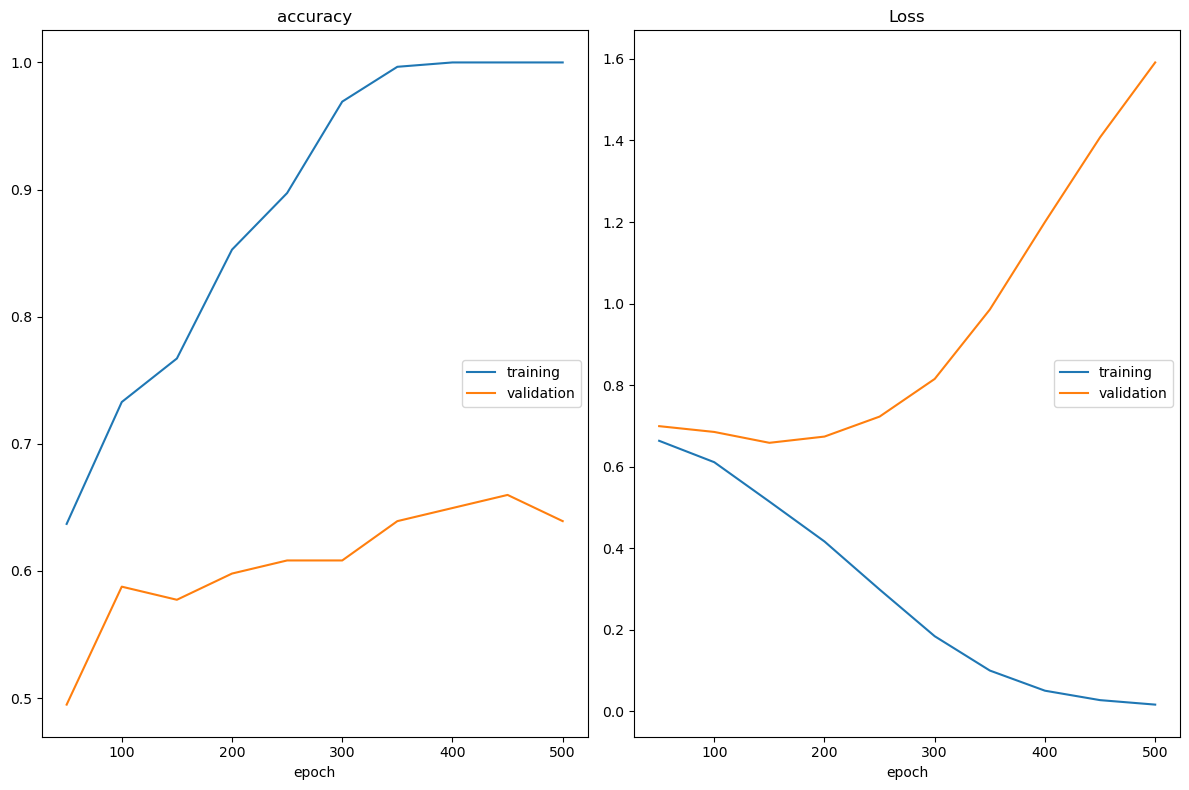

accuracy
	training         	 (min:    0.637, max:    1.000, cur:    1.000)
	validation       	 (min:    0.495, max:    0.660, cur:    0.639)
Loss
	training         	 (min:    0.016, max:    0.663, cur:    0.016)
	validation       	 (min:    0.658, max:    1.591, cur:    1.591)


In [30]:
# YOUR IMPLEMENTATION HERE
# You can use multiple cells if you wish.
def kaiming_init(model):
    for m in model.modules():
        if isinstance(m, (torch.nn.Conv2d, torch.nn.Linear)):
            torch.nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='relu')
            if m.bias is not None:
                torch.nn.init.zeros_(m.bias)

class TreeNetworkKaiming(TreeNetwork):
    def __init__(self):
        super().__init__()
        kaiming_init(self)

set_seed(42)
kaiming_model = train_model(TreeNetworkKaiming, epochs=DEFAULT_EPOCHS)

Did the initialization yield any training improvements? If so, why do you think that is?

What wasy your validation trianing and loss with and without your initialization?

### ANS:
Yes, obviously the He initialization bring the improvement to the training process, but it did not improve validation performance. Compared the model with Kaiming initialization with the baseline model, the training accuracy increased from $0.880$ to $1.000$, and the training loss decreased from $0.278$ to $0.016$. However, the validation accuracy decreased from $0.701$ to $0.639$, and the validation loss increased from $0.660$ to $1.591$. This might indicates that though the model learned the training set better, it also overfit the data more severely then before. Since Kaiming initialization is designed for ReLU activations, it helps maintain a more stable signal scale across different layers, so the model can converge much faster and fit the training data more easily.

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

### Learning Rate (5% of the 25%)

Sometimes a particular learning rate, or simple fixed learning rate does not give the best results. Experiment with learning rates and learning rate schedules to see if you can get an improvement.

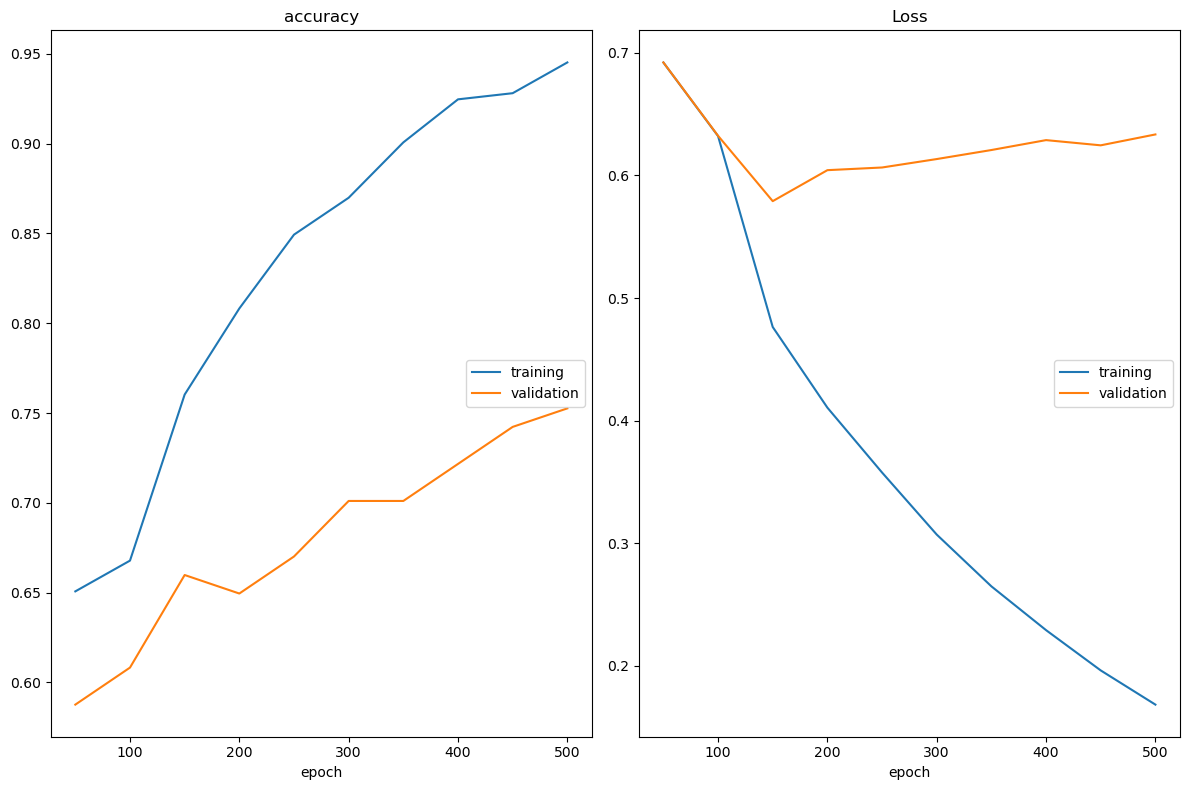

accuracy
	training         	 (min:    0.651, max:    0.945, cur:    0.945)
	validation       	 (min:    0.588, max:    0.753, cur:    0.753)
Loss
	training         	 (min:    0.168, max:    0.692, cur:    0.168)
	validation       	 (min:    0.579, max:    0.692, cur:    0.633)


Best Learning Rate: 0.00016


,learning_rate,train_loss,train_acc,val_loss,val_acc
0,0.00005,0.4247365,0.79452056,0.61814785,0.7010309
1,0.00006,0.3587382,0.8253425,0.6485318,0.6494845
2,0.00007,0.3162894,0.8664383,0.6708903,0.68041235
3,0.00008,0.2984792,0.8767123,0.6846429,0.69072163
4,0.00009,0.28201896,0.89041096,0.6832748,0.7010309
5,0.00010,0.2782462,0.88013697,0.6597309,0.7010309
6,0.00011,0.25878257,0.8938356,0.76059675,0.69072163
7,0.00012,0.23429759,0.91780823,0.74891436,0.68041235
8,0.00013,0.24437058,0.9212329,0.6889831,0.69072163
9,0.00014,0.21383768,0.9349315,0.6920321,0.7113402


In [31]:
# YOUR IMPLEMENTATION HERE
# You can use multiple cells if you wish.
lr_list = [5e-5, 6e-5, 7e-5, 8e-5, 9e-5, 1e-4, 1.1e-4, 1.2e-4, 1.3e-4, 1.4e-4, 1.5e-4, 1.6e-4, 1.7e-4, 1.8e-4, 1.9e-4, 2e-4]

lr_results = {
    "learning_rate": [],
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

# Run the baseline model with the given learning rate and store the results in lr_results
for lr in lr_list:
    set_seed(42)
    lr_model = train_model(TreeNetwork, epochs=DEFAULT_EPOCHS, learning_rate=lr)

    with torch.no_grad():
        lr_model.eval()

        train_pred = lr_model(train_X)
        val_pred = lr_model(validation_X)
        
        lr_results["learning_rate"].append(lr)
        lr_results["train_loss"].append(to_numpy(loss_function(train_pred, train_Y)))
        lr_results["train_acc"].append(to_numpy(torcheval.metrics.functional.multiclass_accuracy(torch.argmax(train_pred, dim=-1), train_Y)))
        lr_results["val_loss"].append(to_numpy(loss_function(val_pred, validation_Y)))
        lr_results["val_acc"].append(to_numpy(torcheval.metrics.functional.multiclass_accuracy(torch.argmax(val_pred, dim=-1), validation_Y)))

    del lr_model

# Select the learning rate with the best validation accuracy
best_idx_lr = np.argmax(lr_results["val_acc"])
best_learning_rate = lr_results["learning_rate"][best_idx_lr]

set_seed(42)
learning_rate_model = train_model(TreeNetwork, epochs=DEFAULT_EPOCHS, learning_rate=best_learning_rate)

print("\n" + "=" * 50)
print(f"\nBest Learning Rate: {best_learning_rate}")

lr_df = pd.DataFrame(lr_results)
lr_df


Did learning rate help? If so, why do you think that is?

What's the best validation accuracy and loss you could achieve compared to the baseline?

## ANS:
Yes, adjusting the learning rate improved the model performance. Since the learning rate controls the step size of gradient updates during optimization, it is important to find an appropriate value to ensure that the model converges to a better minimum. In this case, the best learning rate increased by $0.00006$, which allows the learning process to take larger parameter update steps and move closer to the true global minimum.

In the baseline experiment, the default learning rate of $0.0001$ achieved a validation accuracy of $0.701$ and a validation loss of $0.660$. Among all these candidates, we selected $0.00016$ as the final learning rate. The results show that it achieves a higher validation accuracy of $0.753$ and a lower validation loss of $0.633$.

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

### Regularization (5% of the 25%)

Try different regularization methods to see which one or ones give the best results.

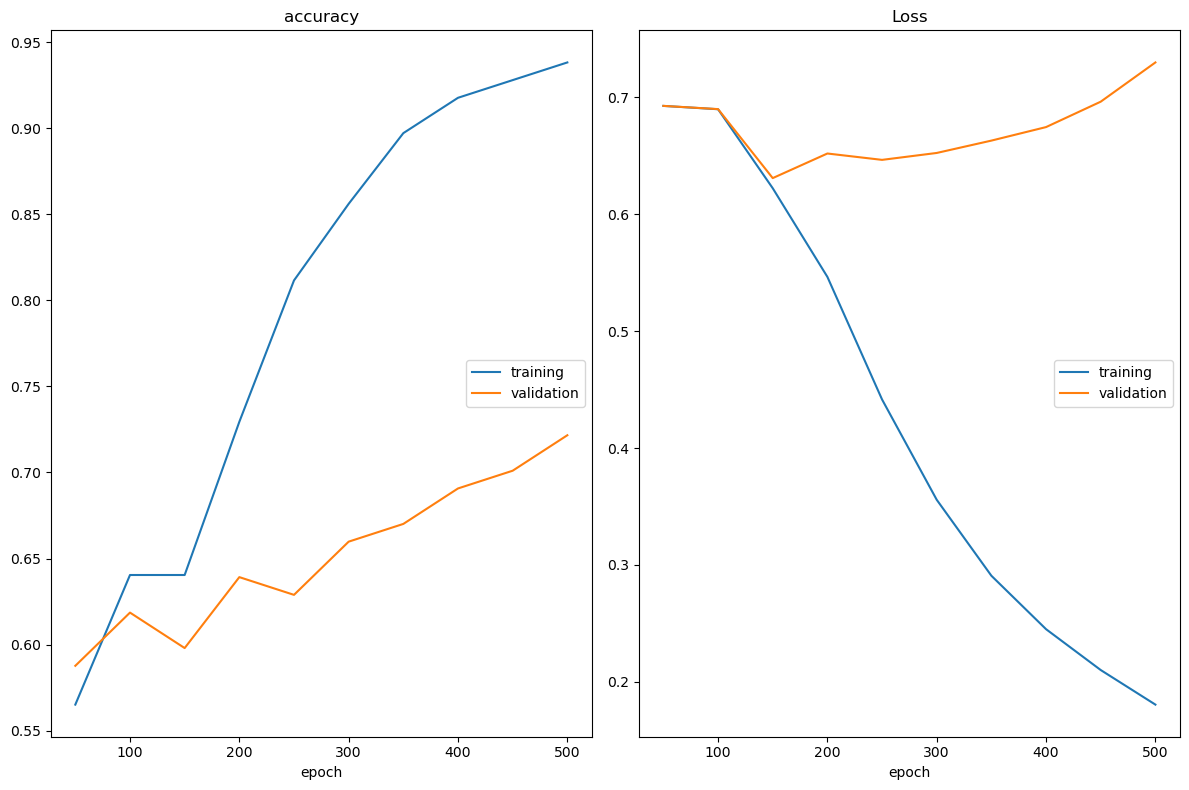

accuracy
	training         	 (min:    0.565, max:    0.938, cur:    0.938)
	validation       	 (min:    0.588, max:    0.722, cur:    0.722)
Loss
	training         	 (min:    0.180, max:    0.693, cur:    0.180)
	validation       	 (min:    0.631, max:    0.730, cur:    0.730)


Best Weight Decay: 5e-08


,weight_decay,train_loss,train_acc,val_loss,val_acc
0,0.000000e+00,0.2782462,0.88013697,0.6597309,0.7010309
1,1.000000e-08,0.27147654,0.8835616,0.65924823,0.7010309
2,5.000000e-08,0.18041879,0.93835616,0.72999704,0.72164947
3,1.000000e-07,0.27250952,0.89041096,0.71536326,0.6701031
4,5.000000e-07,0.26881862,0.89041096,0.7029198,0.68041235
5,1.000000e-06,0.26004675,0.89726025,0.71438986,0.6701031
6,5.000000e-06,0.15250164,0.9691781,0.8878936,0.6185567
7,1.000000e-05,0.2605379,0.9041096,0.78242594,0.68041235
8,5.000000e-05,0.16828322,0.94863015,0.8307862,0.7010309


In [32]:
# YOUR IMPLEMENTATION HERE
# You can use multiple cells if you wish.


def regularization_model(model_class, epochs=DEFAULT_EPOCHS, learning_rate=1e-4, weight_decay=1e-4, **kwargs):
    """
    Train a model for a given number of epochs and plot the loss and accuracy for the training and validation sets.
    # NOTE: Basically the same as train_model(), but with L2 regularization added to the loss function.
    """
    model = model_class(**kwargs)
    if torch.cuda.is_available():
        model = model.cuda()

    model = torch.nn.DataParallel(model)
    model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

    liveloss = livelossplot.PlotLosses()
    for i in range(epochs):
        model.train()

        optimizer.zero_grad(set_to_none=True)
        prediction = model(train_X)
        loss = loss_function(prediction, train_Y)
        loss.backward()
        optimizer.step()

        if (i + 1) % 50 == 0:
            liveloss_updates = {}
            with torch.no_grad():
                model.eval()

                def get_metrics(metrics_prefix, metrics_X, metrics_Y):
                    metrics_prediction = model(metrics_X)

                    return {
                        f"{metrics_prefix}loss": loss_function(metrics_prediction, metrics_Y),
                        f"{metrics_prefix}accuracy": torcheval.metrics.functional.multiclass_accuracy(torch.argmax(metrics_prediction, dim=-1), metrics_Y)
                    }
                
                liveloss_updates.update(get_metrics("", train_X, train_Y))
                liveloss_updates.update(get_metrics("val_", validation_X, validation_Y))

            liveloss_updates = {k: to_numpy(v) for k, v in liveloss_updates.items()}
            liveloss.update(liveloss_updates,
                            current_step=i+1)
            liveloss.send()

    return model

# Now, we want to choose the best lambda for L2 regularization. 

wd_list = [0, 1e-8, 5e-8, 1e-7, 5e-7, 1e-6, 5e-6, 1e-5, 5e-5]

wd_results = {
    "weight_decay": [],
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

# Run the baseline model with the given learning rate and store the results in lr_results
for wd in wd_list:
    set_seed(42)
    wd_model = regularization_model(TreeNetwork, epochs=DEFAULT_EPOCHS, weight_decay=wd)

    with torch.no_grad():
        wd_model.eval()

        train_pred = wd_model(train_X)
        val_pred = wd_model(validation_X)

        wd_results["weight_decay"].append(wd)
        wd_results["train_loss"].append(to_numpy(loss_function(train_pred, train_Y)))
        wd_results["train_acc"].append(to_numpy(torcheval.metrics.functional.multiclass_accuracy(torch.argmax(train_pred, dim=-1), train_Y)))
        wd_results["val_loss"].append(to_numpy(loss_function(val_pred, validation_Y)))
        wd_results["val_acc"].append(to_numpy(torcheval.metrics.functional.multiclass_accuracy(torch.argmax(val_pred, dim=-1), validation_Y)))

    del wd_model

# Select the weight decay with the best validation accuracy
# In this case, we might have multiple weight decay values with the same validation accuracy, so we can select the one with the lowest 
# validation loss among those with the highest validation accuracy.
val_acc_array = np.array(wd_results["val_acc"])
val_loss_array = np.array(wd_results["val_loss"])

best_val_acc = np.max(val_acc_array)
candidate_idx = np.where(val_acc_array == best_val_acc)[0]

best_idx_wd = candidate_idx[np.argmin(val_loss_array[candidate_idx])]
best_weight_decay = wd_results["weight_decay"][best_idx_wd]

set_seed(42)
l2_regularization_model = regularization_model(TreeNetwork, epochs=DEFAULT_EPOCHS, weight_decay=best_weight_decay)

print("\n" + "=" * 50)
print(f"\nBest Weight Decay: {best_weight_decay}")

wd_df = pd.DataFrame(wd_results)
wd_df

What are different types of regularization methods?

Which ones did you try?

Which worked the best and why do you think that is?

What is the improvement validation accuracy and loss over baseline?

## ANS:
There are multiple ways to perform regularization, such as L1 regularization, L2 regularization (weight decay), dropout, ensembling, and even early stopping can be considered a form of regularization. These methods aim to prevent the model from relying too heavily on specific parameters and help improve generalization on unseen data.

In this experiment, I applied one of the most common approaches: L2 regularization. I tested several values of the weight decay parameter ranging from $5 \times 10^{-5}$ to $0$ in order to evaluate their effects on training and validation performance. Among all the tested values, the best result was obtained when the weight decay was set to $5 \times 10^{-8}$.

Although this regularization setting increased the validation loss compared to the baseline model, it improved the validation accuracy. The baseline model achieved a validation accuracy of $0.701$ with a validation loss of $0.660$, while the model with weight decay achieved a higher validation accuracy of $0.722$ compared with the loss $0.730$. 

Therefore, despite the slightly higher validation loss, the model with weight decay demonstrates better classification performance and generalization ability on the validation set.

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

## Data Augmentation (5% of the 25%)

This is a relatively small dataset. In such cases data augmentation may help with generalization.

Try different data augmentations and report the results and improvements.

In [33]:
# YOUR IMPLEMENTATION HERE
# You can use multiple cells if you wish.

# Transform a single image with the given augmentation
def augment_one_image(x, aug_name):
    """
    x: single image tensor, shape = (C, H, W), values in [0,1]
    """
    if aug_name is None:
        return x

    if aug_name == "flip":
        if torch.rand(1).item() < 0.5:
            x = TF.hflip(x)
        return x

    elif aug_name == "rotate_crop":
        angle = float(torch.empty(1).uniform_(-15, 15).item())
        h, w = x.shape[-2:]

        x = TF.rotate(x, angle, interpolation=InterpolationMode.BILINEAR)

        crop_h = int(h * 0.9)
        crop_w = int(w * 0.9)
        top = (h - crop_h) // 2
        left = (w - crop_w) // 2

        x = TF.crop(x, top, left, crop_h, crop_w)
        x = TF.resize(x, [h, w], interpolation=InterpolationMode.BILINEAR)
        return x.clamp(0, 1)

    elif aug_name == "vertical_stretch":
        h, w = x.shape[-2:]
        scale = float(torch.empty(1).uniform_(0.85, 1.15).item())
        new_h = max(1, int(h * scale))

        x = F.interpolate(x.unsqueeze(0), size=(new_h, w), mode="bilinear", align_corners=False).squeeze(0)
        x = F.interpolate(x.unsqueeze(0), size=(h, w), mode="bilinear", align_corners=False).squeeze(0)
        return x.clamp(0, 1)

    elif aug_name == "color_balance":
        brightness = float(torch.empty(1).uniform_(0.8, 1.2).item())
        contrast = float(torch.empty(1).uniform_(0.8, 1.2).item())

        x = TF.adjust_brightness(x, brightness)
        x = TF.adjust_contrast(x, contrast)
        return x.clamp(0, 1)

    elif aug_name == "blur":
        sigma = float(torch.empty(1).uniform_(0.1, 1.2).item())
        x = TF.gaussian_blur(x, kernel_size=[5, 5], sigma=[sigma, sigma])
        return x.clamp(0, 1)

    else:
        raise ValueError(f"Unknown augmentation: {aug_name}")

# Transform all the images in a batch with the given augmentation
def augment_batch(X, aug_name):
    """
    X: batch tensor, shape = (N, C, H, W)
    """
    if aug_name is None:
        return X
    return torch.stack([augment_one_image(img, aug_name) for img in X], dim=0)

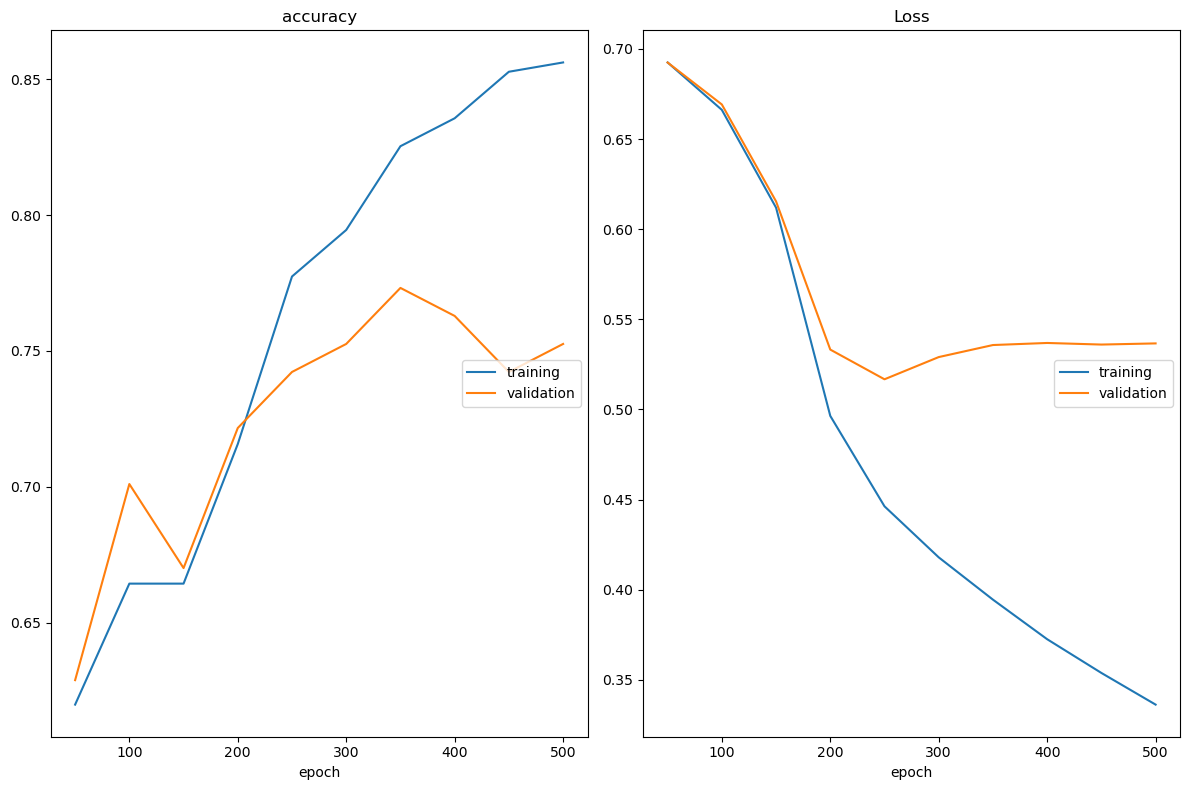

accuracy
	training         	 (min:    0.620, max:    0.856, cur:    0.856)
	validation       	 (min:    0.629, max:    0.773, cur:    0.753)
Loss
	training         	 (min:    0.336, max:    0.692, cur:    0.336)
	validation       	 (min:    0.517, max:    0.692, cur:    0.537)


Best Augmentation: flip


,augmentation,train_loss,train_acc,val_loss,val_acc
0,flip,0.33629227,0.8561644,0.53663695,0.7525773
1,rotate_crop,0.37642202,0.8287671,0.68149906,0.68041235
2,vertical_stretch,0.22726066,0.90753424,0.745396,0.6494845
3,color_balance,0.38314152,0.8356164,0.6022961,0.68041235
4,blur,0.25019938,0.90068495,0.7699484,0.6494845
5,None (baseline),0.157533,0.962329,0.759436,0.721649


In [34]:
def augmentation_model(model_class, epochs=DEFAULT_EPOCHS, learning_rate=1e-4, augmentation=None, **kwargs):
    """
    Train a model with data augmentation applied only to training data.
    """
    model = model_class(**kwargs)
    if torch.cuda.is_available():
        model = model.cuda()

    model = torch.nn.DataParallel(model)
    model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    liveloss = livelossplot.PlotLosses()
    for i in range(epochs):
        model.train()

        optimizer.zero_grad(set_to_none=True)

        # apply augmentation only on train set
        aug_train_X = augment_batch(train_X, augmentation)
        prediction = model(aug_train_X)

        loss = loss_function(prediction, train_Y)
        loss.backward()
        optimizer.step()

        if (i + 1) % 50 == 0:
            liveloss_updates = {}
            with torch.no_grad():
                model.eval()

                def get_metrics(metrics_prefix, metrics_X, metrics_Y):
                    metrics_prediction = model(metrics_X)
                    return {
                        f"{metrics_prefix}loss": loss_function(metrics_prediction, metrics_Y),
                        f"{metrics_prefix}accuracy": torcheval.metrics.functional.multiclass_accuracy(
                            torch.argmax(metrics_prediction, dim=-1), metrics_Y
                        )
                    }

                liveloss_updates.update(get_metrics("", train_X, train_Y))
                liveloss_updates.update(get_metrics("val_", validation_X, validation_Y))

            liveloss_updates = {k: to_numpy(v) for k, v in liveloss_updates.items()}
            liveloss.update(liveloss_updates, current_step=i+1)
            liveloss.send()

    return model

# Now test the augmentation model with different augmentation
aug_list = ["flip", "rotate_crop", "vertical_stretch", "color_balance", "blur"]

aug_results = {
    "augmentation": [],
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

for aug in aug_list:
    set_seed(42)
    print(f"Testing augmentation = {aug}")

    aug_model = augmentation_model(
        TreeNetwork,
        epochs=DEFAULT_EPOCHS,
        learning_rate=best_learning_rate,
        augmentation=aug
    )

    with torch.no_grad():
        aug_model.eval()

        train_pred = aug_model(train_X)
        val_pred = aug_model(validation_X)

        aug_results["augmentation"].append(str(aug))
        aug_results["train_loss"].append(to_numpy(loss_function(train_pred, train_Y)))
        aug_results["train_acc"].append(
            to_numpy(torcheval.metrics.functional.multiclass_accuracy(torch.argmax(train_pred, dim=-1), train_Y))
        )
        aug_results["val_loss"].append(to_numpy(loss_function(val_pred, validation_Y)))
        aug_results["val_acc"].append(
            to_numpy(torcheval.metrics.functional.multiclass_accuracy(torch.argmax(val_pred, dim=-1), validation_Y))
        )

    del aug_model

# Add the baseline model with no augmentation to the results for comparison
base_train_loss = 0.15753327
base_train_acc  = 0.96232873
base_val_loss   = 0.759436
base_val_acc    = 0.72164947

aug_results["augmentation"].append("None (baseline)")
aug_results["train_loss"].append(base_train_loss)
aug_results["train_acc"].append(base_train_acc)
aug_results["val_loss"].append(base_val_loss)
aug_results["val_acc"].append(base_val_acc)

# Select the augmentation with the best validation accuracy. Similar to before
val_acc_array = np.array(aug_results["val_acc"])
val_loss_array = np.array(aug_results["val_loss"])

best_val_acc = np.max(val_acc_array)

candidate_idx = np.where(val_acc_array == best_val_acc)[0]

best_idx_aug = candidate_idx[np.argmin(val_loss_array[candidate_idx])]
best_augmentation = aug_results["augmentation"][best_idx_aug]

set_seed(42)
augmentation_best_model = augmentation_model(
    TreeNetwork,
    epochs=DEFAULT_EPOCHS,
    learning_rate=best_learning_rate,
    augmentation=best_augmentation
)

print("\n" + "=" * 50)
print(f"\nBest Augmentation: {best_augmentation}")

aug_df = pd.DataFrame(aug_results)
aug_df
    

What data augmentation methods did you use?

How much of an improvement did you get over the baseline validation accuracy and loss?

## ANS:  
I tested different augmentation techniques in this experiment including horizontal flipping, rotation with cropping, vertical stretching, color balance adjustment, and Gaussian blur.

Among all the tested augmentation methods, horizontal flipping produced the best result. The baseline model (without augmentation) achieved a validation accuracy of $0.701$ with a validation loss of $0.660$. When horizontal flipping was applied, the validation accuracy increased to $0.753$, while the validation loss decreased to $0.537$. Therefore, horizontal flipping was selected as the best augmentation method because it achieved both the highest validation accuracy and the lowest validation loss among all the tested methods.

Overall, among all the techniques explored so far, data augmentation provides the largest improvement. It effectively reduces overfitting while simultaneously improving the model’s validation accuracy and lowering the validation loss, resulting in better generalization performance.

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

## Training All Combinations (30%)

Take the best configuration of each of the five training modifications and apply them all to see what overall improvement you can get.

Note that it is possible that some improvements negatively impact other improvements. If you want to be truly rigorous you would implement a training function that takes arguments for each of the improvements so you can sweep through all the combinations. In fact there are experiment tracking tools that help you do this like [Weights and Bias Sweeps](https://docs.wandb.ai/models/sweeps). It is free for students by the way.

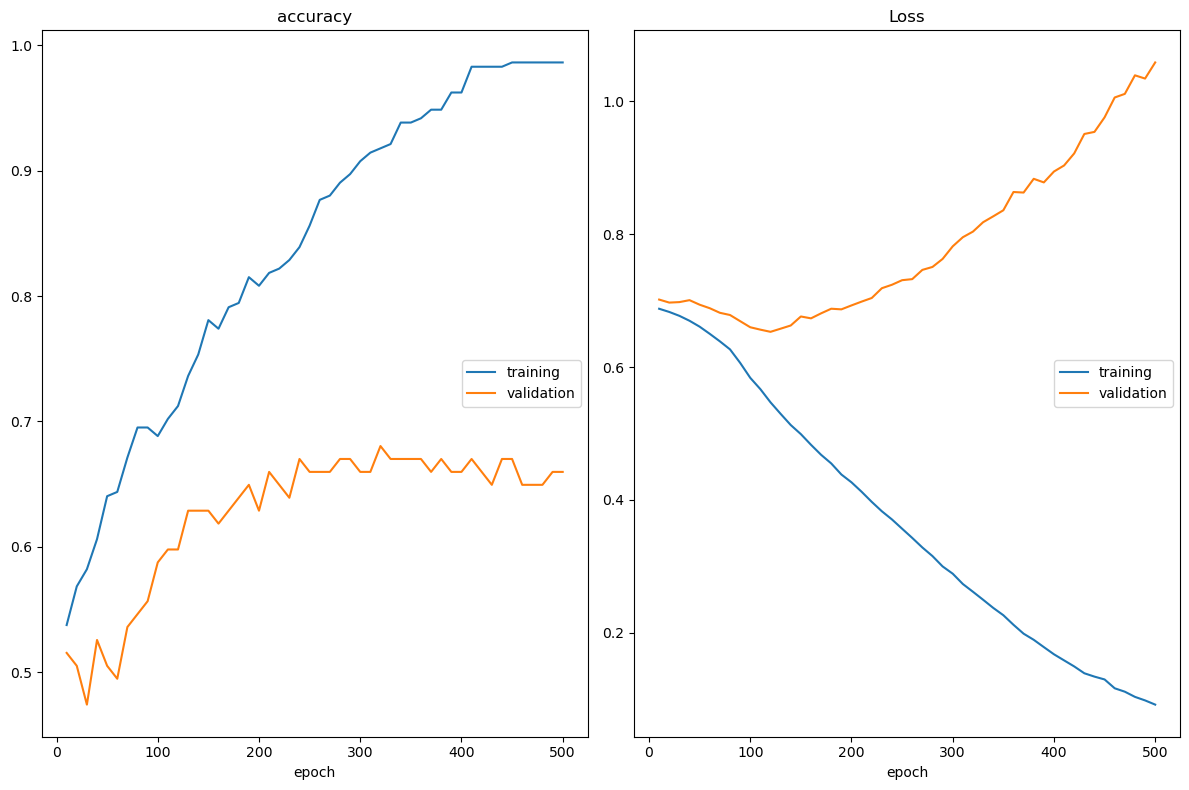

accuracy
	training         	 (min:    0.538, max:    0.986, cur:    0.986)
	validation       	 (min:    0.474, max:    0.680, cur:    0.660)
Loss
	training         	 (min:    0.092, max:    0.688, cur:    0.092)
	validation       	 (min:    0.653, max:    1.058, cur:    1.058)


In [46]:
# YOUR IMPLEMENTATION HERE
# You can use multiple cells if you wish.

# These are the best params found from the previous experiments.
# Let's try it once
old_best_epoch = 500
old_best_learning_rate = 1.6e-4
old_best_weight_decay = 5e-08
old_best_augmentation = "flip"


def train_best_model_old(model_class, epochs, learning_rate, weight_decay, augmentation=None, **kwargs):
    """
    Train my best model applied to training data.
    """
    model = model_class(**kwargs)
    if torch.cuda.is_available():
        model = model.cuda()

    model = torch.nn.DataParallel(model)
    model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

    liveloss = livelossplot.PlotLosses()
    for i in range(epochs):
        model.train()

        optimizer.zero_grad(set_to_none=True)

        # apply augmentation only on train set
        aug_train_X = augment_batch(train_X, augmentation)
        prediction = model(aug_train_X)

        loss = loss_function(prediction, train_Y)
        loss.backward()
        optimizer.step()

        if (i + 1) % 10 == 0:
            liveloss_updates = {}
            with torch.no_grad():
                model.eval()

                def get_metrics(metrics_prefix, metrics_X, metrics_Y):
                    metrics_prediction = model(metrics_X)
                    return {
                        f"{metrics_prefix}loss": loss_function(metrics_prediction, metrics_Y),
                        f"{metrics_prefix}accuracy": torcheval.metrics.functional.multiclass_accuracy(
                            torch.argmax(metrics_prediction, dim=-1), metrics_Y
                        )
                    }

                liveloss_updates.update(get_metrics("", train_X, train_Y))
                liveloss_updates.update(get_metrics("val_", validation_X, validation_Y))

            liveloss_updates = {k: to_numpy(v) for k, v in liveloss_updates.items()}
            liveloss.update(liveloss_updates, current_step=i+1)
            liveloss.send()

    return model

set_seed(42)
best_model = train_best_model_old(
    TreeNetworkKaiming, 
    epochs=old_best_epoch, 
    learning_rate=old_best_learning_rate, 
    weight_decay=old_best_weight_decay, 
    augmentation=old_best_augmentation
)

Obviously, the result becomes much worse than before (validation loss with a large increase). Therefore, in the following section, we will further fine-tune the best model.

### Best Model Fine-Tuning

In [36]:
# New augment method
def augment_one_image_new(x):
    if torch.rand(1).item() < 0.5:
        x = TF.hflip(x)

    # only apply rotation with probability 0.3
    if torch.rand(1).item() < 0.3:
        angle = float(torch.empty(1).uniform_(-10, 10).item())
        h, w = x.shape[-2:]

        x = TF.rotate(x, angle, interpolation=InterpolationMode.BILINEAR)

        crop_h = int(h * 0.95)
        crop_w = int(w * 0.95)
        top = (h - crop_h) // 2
        left = (w - crop_w) // 2

        x = TF.crop(x, top, left, crop_h, crop_w)
        x = TF.resize(x, [h, w], interpolation=InterpolationMode.BILINEAR)

    return x.clamp(0, 1)

# Transform all the images in a batch with the new augmentation
def best_augment_batch(X):
    """
    X: batch tensor, shape = (N, C, H, W)
    """
    return torch.stack([augment_one_image_new(img) for img in X], dim=0)

In [ ]:
# Try mini-batch training for the best model
from torch.utils.data import TensorDataset, DataLoader

def train_best_model(model_class, epochs, learning_rate, weight_decay, batch_size=32, **kwargs):
    """
    Train the best combined model with mini-batch training.
    """
    model = model_class(**kwargs)
    if torch.cuda.is_available():
        model = model.cuda()

    model = torch.nn.DataParallel(model)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

    # build mini-batch loader
    train_ds = TensorDataset(train_X, train_Y)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

    liveloss = livelossplot.PlotLosses()

    for i in range(epochs):
        model.train()

        for X_batch, y_batch in train_loader:
            if torch.cuda.is_available():
                X_batch = X_batch.cuda()
                y_batch = y_batch.cuda()

            optimizer.zero_grad(set_to_none=True)

            # apply augmentation only to the current batch
            aug_X_batch = best_augment_batch(X_batch)
            prediction = model(aug_X_batch)

            loss = loss_function(prediction, y_batch)
            loss.backward()
            optimizer.step()

        if (i + 1) % 50 == 0:
            liveloss_updates = {}

            with torch.no_grad():
                model.eval()

                def get_metrics(metrics_prefix, metrics_X, metrics_Y):
                    metrics_prediction = model(metrics_X)
                    return {
                        f"{metrics_prefix}loss": loss_function(metrics_prediction, metrics_Y),
                        f"{metrics_prefix}accuracy": torcheval.metrics.functional.multiclass_accuracy(
                            torch.argmax(metrics_prediction, dim=-1), metrics_Y
                        )
                    }

                liveloss_updates.update(get_metrics("", train_X, train_Y))
                liveloss_updates.update(get_metrics("val_", validation_X, validation_Y))

            liveloss_updates = {k: to_numpy(v) for k, v in liveloss_updates.items()}
            liveloss.update(liveloss_updates, current_step=i + 1)
            liveloss.send()

    return model

We assume that Kaiming has better optimization, worse generalization, so we use the orignial method instead.

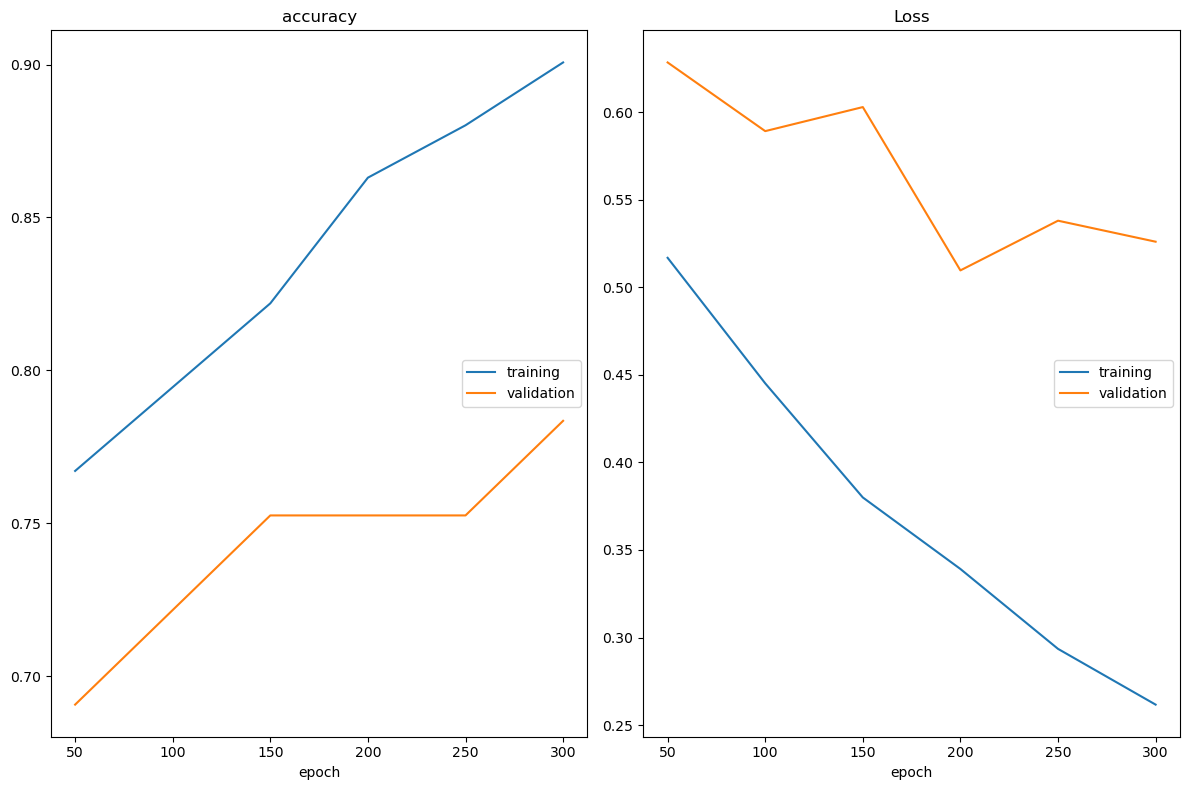

accuracy
	training         	 (min:    0.767, max:    0.901, cur:    0.901)
	validation       	 (min:    0.691, max:    0.784, cur:    0.784)
Loss
	training         	 (min:    0.262, max:    0.517, cur:    0.262)
	validation       	 (min:    0.510, max:    0.628, cur:    0.526)

Best combination found
learning_rate = 0.0002
weight_decay  = 1e-08
val_acc       = 0.783505
val_loss      = 0.526073


,learning_rate,weight_decay,train_loss,train_acc,val_loss,val_acc
91,0.00020,1.000000e-08,0.261692,0.900685,0.526073,0.783505
87,0.00018,5.000000e-06,0.291428,0.876712,0.603341,0.783505
96,0.00020,5.000000e-06,0.385055,0.818493,0.506824,0.773196
47,0.00010,5.000000e-08,0.434430,0.791096,0.589503,0.773196
75,0.00016,1.000000e-07,0.323843,0.859589,0.626870,0.773196
...,...,...,...,...,...,...
7,0.00001,1.000000e-05,0.682110,0.667808,0.684255,0.608247
4,0.00001,5.000000e-07,0.675042,0.619863,0.679359,0.597938
3,0.00001,1.000000e-07,0.676338,0.640411,0.680235,0.587629
2,0.00001,5.000000e-08,0.677312,0.643836,0.680895,0.587629


In [41]:
import itertools

# fixed settings for final combo search
combo_epoch = 300 
# for epoch = 300, it seems to have good validation accuracy while not overfitting too much based on the previous experiments.


lr_list = [
    1e-5, 2e-5, 4e-5, 6e-5, 8e-5, 
    1.0e-4, 1.2e-4, 1.4e-4, 1.6e-4, 1.8e-4, 2.0e-4
]
wd_list = [0, 1e-8, 5e-8, 1e-7, 5e-7, 1e-6, 5e-6, 1e-5, 5e-5]

combo_results = {
    "learning_rate": [],
    "weight_decay": [],
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

# sweep all lr x wd combinations
for lr, wd in itertools.product(lr_list, wd_list):
    print(f"Testing lr={lr}, wd={wd}")
    set_seed(42)

    combo_model = train_best_model(
        TreeNetwork,
        epochs=combo_epoch,
        learning_rate=lr,
        weight_decay=wd,
        batch_size=32
    )

    with torch.no_grad():
        combo_model.eval()

        train_pred = combo_model(train_X)
        val_pred = combo_model(validation_X)

        combo_results["learning_rate"].append(lr)
        combo_results["weight_decay"].append(wd)
        combo_results["train_loss"].append(float(loss_function(train_pred, train_Y)))
        combo_results["train_acc"].append(
            float(
                torcheval.metrics.functional.multiclass_accuracy(
                    torch.argmax(train_pred, dim=-1), train_Y
                )
            )
        )
        combo_results["val_loss"].append(float(loss_function(val_pred, validation_Y)))
        combo_results["val_acc"].append(
            float(
                torcheval.metrics.functional.multiclass_accuracy(
                    torch.argmax(val_pred, dim=-1), validation_Y
                )
            )
        )

    del combo_model

######################################

# make dataframe
combo_df = pd.DataFrame(combo_results)

# choose best: highest val_acc, tie-break by lowest val_loss
best_row = combo_df.sort_values(
    ["val_acc", "val_loss"],
    ascending=[False, True]
).iloc[0]

best_lr_combo = best_row["learning_rate"]
best_wd_combo = best_row["weight_decay"]

# retrain best combo once to get final curve
set_seed(42)
best_combo_model = train_best_model(
    TreeNetwork,
    epochs=combo_epoch,
    learning_rate=best_lr_combo,
    weight_decay=best_wd_combo,
    batch_size=32
)

print("\n" + "=" * 60)
print("Best combination found")
print(f"learning_rate = {best_lr_combo}")
print(f"weight_decay  = {best_wd_combo}")
print(f"val_acc       = {best_row['val_acc']:.6f}")
print(f"val_loss      = {best_row['val_loss']:.6f}")
print("=" * 60)

display(combo_df.sort_values(["val_acc", "val_loss"], ascending=[False, True]))

What is your validation accuracy and loss compared to the baseline?

The baseline model achieved a training accuracy of $0.880$ with a training loss of $0.278$, while the validation accuracy was $0.701$ and the validation loss was $0.660$. Although the model fit the training data well, there was still a noticeable gap between training and validation performance.

To further improve the model, several training modifications were combined. First, the model was trained using **mini-batch training with a batch size of 32**, which allows the optimizer to update parameters more frequently and improves the stability of gradient updates. Second, **L2 regularization (weight decay = 1e-8)** was applied to prevent the model from relying too heavily on specific parameters and to reduce overfitting. Last, we set the **learning rate** and **epoch** as **0.0002** and **300**.

In addition, **data augmentation** was introduced to increase the diversity of the training data. The augmentation strategy combines **horizontal flipping and random rotation with cropping**. For each image, horizontal flipping is applied with a probability of 0.5. Additionally, with a probability of 0.3, the image is randomly rotated within the range of **−10° to 10°**, followed by a slight **center crop (95% of the original size)** and resizing back to the original resolution. This augmentation process generates different variations of the same training images and helps the model learn more robust features.

After combining these improvements, the resulting **best_combo_model** demonstrated improved performance compared with the baseline. The use of mini-batch training, weight decay regularization, and data augmentation helps the model generalize better by reducing overfitting and exposing the model to more diverse training samples.

# TEST

In [51]:
# # retrain best combo once to get final curve
# set_seed(42)
# best_combo_model = train_best_model(
#     TreeNetwork,
#     epochs=300,
#     learning_rate=best_lr_combo,
#     weight_decay=best_wd_combo,
#     batch_size=32
# )

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

## Validate Set 2 (10%)

Test your best model again with the validation2 data.

Use your existing models trained and do not retrain them using the validation2 data.

In [52]:
# YOUR IMPLEMENTATION HERE
# You can use multiple cells if you wish.

with torch.no_grad():
    best_combo_model.eval()

    # validation set 1
    val1_pred = best_combo_model(validation_X)
    val1_loss = loss_function(val1_pred, validation_Y)
    val1_acc = torcheval.metrics.functional.multiclass_accuracy(
        torch.argmax(val1_pred, dim=-1),
        validation_Y
    )

    # validation set 2
    val2_pred = best_combo_model(validation2_X)
    val2_loss = loss_function(val2_pred, validation2_Y)
    val2_acc = torcheval.metrics.functional.multiclass_accuracy(
        torch.argmax(val2_pred, dim=-1),
        validation2_Y
    )

# Show the results
print("Validation Set 1")
print(f"Loss: {val1_loss.item():.4f}")
print(f"Accuracy: {val1_acc.item():.4f}")

print("\nValidation Set 2")
print(f"Loss: {val2_loss.item():.4f}")
print(f"Accuracy: {val2_acc.item():.4f}")

Validation Set 1
Loss: 0.5261
Accuracy: 0.7835

Validation Set 2
Loss: 0.6541
Accuracy: 0.7130


Report you accuracy and loss of validation set 2 vs validation set 1.

Any surprises? If so, can you explain why?

<!-- END QUESTION -->

If your new validation results are poor, you may go back and refine your training improvements, but avoid using validation2 when you do so.

## ANS:
For the best model configuration, the performance on the two validation sets is:

- **Validation Set 1:**  
  - Accuracy: **0.7835**  
  - Loss: **0.5261**

- **Validation Set 2:**  
  - Accuracy: **0.7130**  
  - Loss: **0.6541**

Compared to Validation Set 1, the model performs worse on Validation Set 2. The accuracy drops from **0.7835 to 0.7130**, and the loss increases from **0.5261 to 0.6541**.

This difference is not surprising because Validation Set 2 represents unseen data that was not used during the model development process. Throughout the experiments, model design choices such as learning rate, weight decay, and data augmentation were tuned using Validation Set 1. As a result, the model may become slightly optimized for the distribution of Validation Set 1.

When evaluated on Validation Set 2, we can treat it as an independent test set that the model has never seen before.

<!-- BEGIN QUESTION -->

## Save Best Model for Auto-Grader Evaluation (30%)

Use `torch.save` to save your best performing model as "best.pt".
Check the auto-grader results as soon as possible to confirm that it can load your model.

Hint: The auto-grader will check this model's accuracy on a withheld test set.
Review your results above and tweak your improvements as you feel appropriate.
But beware, overfitting on the visible data sets will likely lead to poor performance on the withheld test set.

In [53]:
# Save your best model with torch.save as "best.pt"
# replace `base_model` with the name of your best model

# if model may be wrapped in DataParallel
to_save = best_combo_model.module.state_dict() if hasattr(best_combo_model, "module") else best_combo_model.state_dict()
torch.save(to_save, "best.pt")


<!-- END QUESTION -->

